<div style="text-align: right">Author: Yuktha Bhadane (yb294@cornell.edu)</div>

### Global Emissions Heatmap by Country
This notebook visualizes is a heatmap of CO2e emissions by country,with a logarithmic color scale and highlighted the eight developing countries.

0. Set Up

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import pycountry
from matplotlib.colors import LogNorm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

1. Data Loading and Processing

In [2]:
def load_world_map():
    """
    Load world map data from Natural Earth.
    
    Returns:
    geopandas.GeoDataFrame: World map data
    """
    world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
    return world

def load_emissions_data(path, sheet_name):
    """
    Load emissions data from Excel file.
    
    Parameters:
    path (str): Path to Excel file
    sheet_name (str): Name of sheet containing emissions data
    
    Returns:
    pandas.DataFrame: Emissions data
    """
    df_emissions = pd.read_excel(path, sheet_name=sheet_name)
    return df_emissions

def create_iso_mapping():
    """
    Create mapping from ISO alpha-2 to ISO alpha-3 country codes.
    
    Returns:
    dict: Mapping from ISO alpha-2 to ISO alpha-3 codes
    """
    iso_dict = {country.alpha_2: country.alpha_3 
              for country in pycountry.countries 
              if hasattr(country, 'alpha_2') and hasattr(country, 'alpha_3')}
    return iso_dict

def merge_data(world, df_emissions, iso_dict):
    """
    Add ISO alpha-3 codes to emissions data and merge with world map.
    
    Parameters:
    world (geopandas.GeoDataFrame): World map data
    df_emissions (pandas.DataFrame): Emissions data
    iso_dict (dict): Mapping from ISO alpha-2 to ISO alpha-3 codes
    
    Returns:
    geopandas.GeoDataFrame: World map with emissions data
    """
    # Map ISO alpha-2 to ISO alpha-3 codes
    df_emissions['iso3'] = df_emissions['asset_location'].map(iso_dict)
    
    # Merge emissions data with world map
    world = world.merge(df_emissions[['iso3', 'tot_emissions [Gt]']], 
                      how='left',
                      left_on='ISO_A3',
                      right_on='iso3')
    return world

2. Visualisation

In [5]:
def create_emissions_map(world, highlight_countries):
    """
    Create a map of emissions by country with highlighted countries of interest.
    
    Parameters:
    world (geopandas.GeoDataFrame): World map with emissions data
    highlight_countries (list): List of ISO alpha-3 codes for countries to highlight
    
    Returns:
    matplotlib.figure.Figure: Figure containing the visualization
    """
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(20, 8))
    
    # Plot base map with logarithmic color scale
    im = world.plot(column='tot_emissions [Gt]',
                   ax=ax,
                   legend=False,
                   missing_kwds={'color': '#f8f8f8'},
                   cmap='YlOrRd',
                   norm=LogNorm(vmin=0.0001, vmax=10))
    
    # Add borders for highlighted countries
    world[world['ISO_A3'].isin(highlight_countries)].boundary.plot(
       ax=ax, 
       color='black',
       linewidth=1.5
    )
    
    # Add colorbar with proper logarithmic spacing
    cbar_ax = fig.add_axes([0.4, 0.2, 0.2, 0.01])
    norm = LogNorm(vmin=0.0001, vmax=10)
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
    cbar = plt.colorbar(sm,
                       cax=cbar_ax,
                       orientation='horizontal')
    cbar.ax.tick_params(labelsize=8)
    cbar.ax.set_xlabel('Emissions (Gt)', fontsize=10)
    
    # Remove axis
    ax.axis('off')    
    return fig

3. Execution

Saved plot to global_emissions_heatmap/global_emissions_heatmap.png


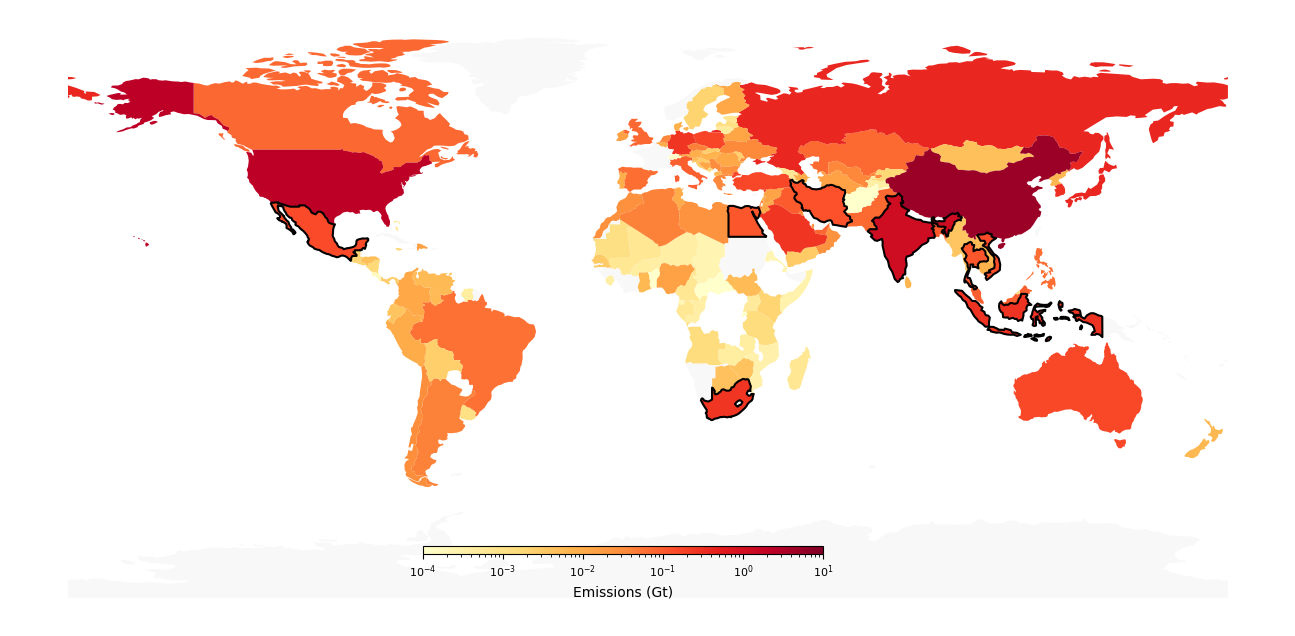

In [6]:
# Note: Update these paths to local or relative paths for GitHub
# Using absolute paths
excel_path = '/Users/yukthabhadane/Documents/Climate Finance Thesis/Paper Alissa Jan 2025/Excel sheets/jupyter To Do 8 and 9 .xlsx'
sheet_name = 'Emi Cap all countries'

# Load world map
world = load_world_map()

# Load emissions data
df_emissions = load_emissions_data(excel_path, sheet_name)

# Create ISO code mapping
iso_dict = create_iso_mapping()

# Merge data
world = merge_data(world, df_emissions, iso_dict)

# Define countries to highlight
highlight_countries = ['IND', 'IDN', 'ZAF', 'MEX', 'VNM', 'IRN', 'THA', 'EGY']

# Create and display visualization
fig = create_emissions_map(world, highlight_countries)

# Create output directory in the same location as this notebook
output_dir = Path("global_emissions_heatmap")
output_dir.mkdir(exist_ok=True, parents=True)

# Save the figure to the output directory
output_file = output_dir / "global_emissions_heatmap.png"
fig.savefig(output_file, bbox_inches='tight', dpi=300)
print(f"Saved plot to {output_file}")

# Display the plot
plt.show()